In [1]:
import pandas as pd

# Load BTC CSV
bnb_df = pd.read_csv(r'feature_datasets\BNB_features.csv', parse_dates=True, index_col=0)

# Define X and y
bnb_y = bnb_df['Close'].shift(-1)          # next-day close price
bnb_X = bnb_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
bnb_X = bnb_X.iloc[:-1]
bnb_y = bnb_y.iloc[:-1]

# Optional: check shapes
print("BNB X shape:", bnb_X.shape)
print("BNB y shape:", bnb_y.shape)

BNB X shape: (915, 29)
BNB y shape: (915,)


## 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(bnb_X) * 0.7)

bnb_X_train = bnb_X.iloc[:split_idx].values
bnb_X_test  = bnb_X.iloc[split_idx:].values

bnb_y_train = bnb_y.iloc[:split_idx].values
bnb_y_test  = bnb_y.iloc[split_idx:].values

# check shapes
print("BNB X_train shape:", bnb_X_train.shape)
print("BNB X_test shape:", bnb_X_test.shape)
print("BNB y_train shape:", bnb_y_train.shape)
print("BNB y_test shape:", bnb_y_test.shape)

BNB X_train shape: (640, 29)
BNB X_test shape: (275, 29)
BNB y_train shape: (640,)
BNB y_test shape: (275,)


In [3]:
bnb_test_dates = bnb_df.index[-len(bnb_X_test):]  # get the dates for test set

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
bnb_X_train_scaled = scaler.fit_transform(bnb_X_train)

# Transform TEST using the same scaler
bnb_X_test_scaled = scaler.transform(bnb_X_test)

# Check shapes
print("Scaled X_train shape:", bnb_X_train_scaled.shape)
print("Scaled X_test shape:", bnb_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
bnb_y_train_scaled = y_scaler.fit_transform(bnb_y_train.reshape(-1,1)).flatten()

# Scale test target
bnb_y_test_scaled = y_scaler.transform(bnb_y_test.reshape(-1,1)).flatten()

In [6]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BNB using scaled target
bnb_X_train_seq, bnb_y_train_seq = create_sequences(bnb_X_train_scaled, bnb_y_train_scaled, time_steps=30)
bnb_X_test_seq, bnb_y_test_seq = create_sequences(bnb_X_test_scaled, bnb_y_test_scaled, time_steps=30)

# Check shapes
print("BNB X_train_seq shape:", bnb_X_train_seq.shape)
print("BNB y_train_seq shape:", bnb_y_train_seq.shape)
print("BNB X_test_seq shape:", bnb_X_test_seq.shape)
print("BNB y_test_seq shape:", bnb_y_test_seq.shape)

BNB X_train_seq shape: (610, 30, 29)
BNB y_train_seq shape: (610,)
BNB X_test_seq shape: (245, 30, 29)
BNB y_test_seq shape: (245,)


### Training the model

In [7]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [8]:
# Get number of features from the sequences
input_size = bnb_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [9]:
model = train_model(
    model,
    bnb_X_train_seq,
    bnb_y_train_seq,
    epochs=50,       
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.010548
Epoch [20/50], Loss: 0.004273
Epoch [30/50], Loss: 0.002838
Epoch [40/50], Loss: 0.001654
Epoch [50/50], Loss: 0.001949


In [10]:
bnb_preds = predict_model(model, bnb_X_test_seq)

# Optional: check
print("Predictions shape:", bnb_preds.shape)
print("First 10 predictions:", bnb_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.27108288]
 [0.2766928 ]
 [0.27235603]
 [0.26592994]
 [0.25986052]
 [0.25559223]
 [0.25315088]
 [0.2532439 ]
 [0.24777721]
 [0.2437461 ]]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
bnb_y_test_actual = bnb_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(bnb_y_test_actual, bnb_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_actual)
mape = np.mean(np.abs((bnb_y_test_actual - bnb_preds_actual) / bnb_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 490.43
RMSE: 22.15
MAE: 19.82
R2 Score: 0.5607
MAPE: 8.56%


In [12]:
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = bnb_df.index[-len(bnb_X_test):][30:]  # test dates aligned with sequences
actual_seq = bnb_y_test[30:]                      # actual prices aligned
pred_seq = bnb_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,321.952698,321.001617
2023-05-03,326.212891,323.566864
2023-05-04,323.917145,321.583771
2023-05-05,326.940308,318.645294
2023-05-06,322.774017,315.869934
...,...,...
2023-12-28,323.598999,284.860077
2023-12-29,313.878754,295.552643
2023-12-30,317.166199,299.357605


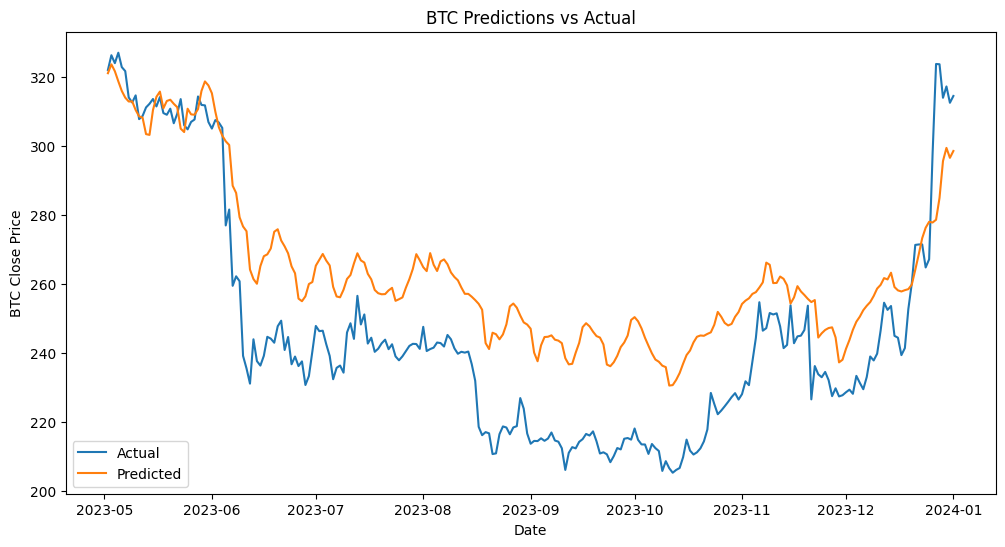

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Every year 70%

### Preparing the train and test datasets

In [15]:
# Get unique years from your DataFrame index
years = bnb_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [16]:
X_train_list = []
y_train_list = []

In [17]:
for year in years:
    # Filter data for this year
    bnb_year = bnb_df[bnb_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(bnb_year) * 0.7)

    # Take first 70% as training
    X_train_year = bnb_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = bnb_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [18]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [19]:
X_test_list = []
y_test_list = []

In [20]:
for year in years:
    bnb_year = bnb_df[bnb_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(bnb_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = bnb_year.iloc[split_idx:, 1:].values   # features
    y_test_year = bnb_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [21]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [23]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

In [24]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [25]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Training the model

In [26]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [27]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [28]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.002221
Epoch [20/50], Loss: 0.001948
Epoch [30/50], Loss: 0.001600
Epoch [40/50], Loss: 0.000937
Epoch [50/50], Loss: 0.001283


In [29]:
bnb_preds_ev_year =predict_model(model_y, X_test_seq)
bnb_preds_ev_year[:10]

array([[0.81791997],
       [0.81963706],
       [0.83724654],
       [0.8516607 ],
       [0.85177505],
       [0.8304212 ],
       [0.81313443],
       [0.81046605],
       [0.77116215],
       [0.7433945 ]], dtype=float32)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
bnb_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
bnb_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(bnb_y_test_actual, bnb_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_actual)
mape = np.mean(np.abs((bnb_y_test_actual - bnb_preds_actual) / bnb_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 418.36
RMSE: 20.45
MAE: 11.99
R2 Score: 0.9527
MAPE: 4.26%


In [31]:
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds_ev_year.reshape(-1, 1))

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = bnb_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_bnb_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_bnb_plot_year.head()

,Actual,Predicted
0,589.256165,533.703003
1,579.689880,534.409790
2,607.592773,541.657959
3,571.648987,547.590881
4,552.966858,547.637939


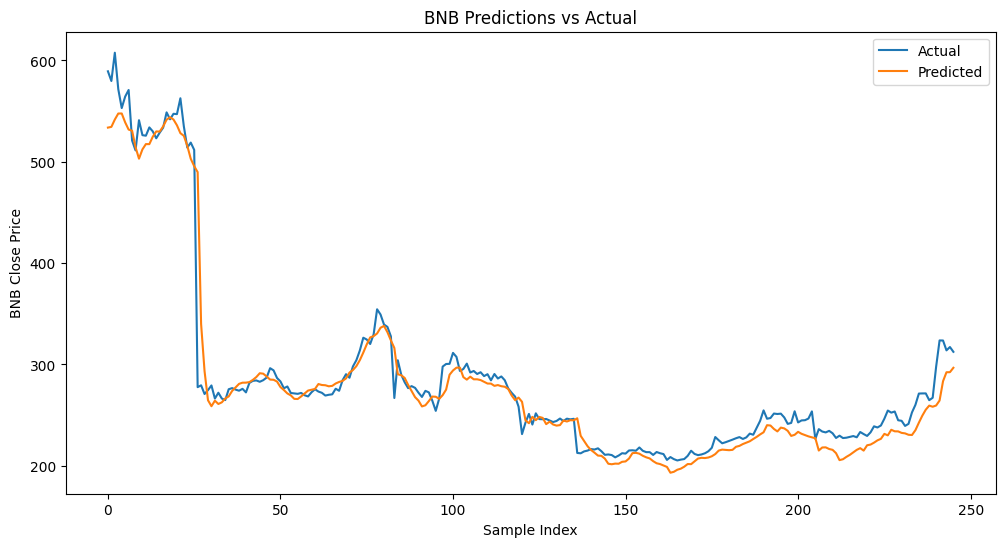

In [33]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_bnb_plot_year["Actual"], label="Actual")
plt.plot(df_bnb_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("BNB Close Price")
plt.title("BNB Predictions vs Actual")
plt.legend()
plt.show()

## Three quarters train (all years-75%)

### train and test set preparation

In [34]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(bnb_X) * 0.75)

bnb_q3_X_train = bnb_X.iloc[:q3_split_idx].values
bnb_q3_X_test  = bnb_X.iloc[q3_split_idx:].values

bnb_q3_y_train = bnb_y.iloc[:q3_split_idx].values
bnb_q3_y_test  = bnb_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 BNB X_train shape:", bnb_q3_X_train.shape)
print("Q3 BNB X_test shape:", bnb_q3_X_test.shape)
print("Q3 BNB y_train shape:", bnb_q3_y_train.shape)
print("Q3 BNB y_test shape:", bnb_q3_y_test.shape)

Q3 BNB X_train shape: (686, 29)
Q3 BNB X_test shape: (229, 29)
Q3 BNB y_train shape: (686,)
Q3 BNB y_test shape: (229,)


In [35]:
# Assuming btc_df has Date as index
bnb_q3_test_dates = bnb_df.index[-len(bnb_q3_X_test):]

print("Q3 test dates length:", len(bnb_q3_test_dates))

Q3 test dates length: 229


In [36]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
bnb_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
bnb_q3_X_train_scaled = bnb_q3_X_scaler.fit_transform(bnb_q3_X_train)

# Transform TEST using same scaler
bnb_q3_X_test_scaled = bnb_q3_X_scaler.transform(bnb_q3_X_test)

print("Q3 Scaled X_train shape:", bnb_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", bnb_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [37]:
# Target scaler
bnb_q3_y_scaler = MinMaxScaler()

# Scale training target
bnb_q3_y_train_scaled = bnb_q3_y_scaler.fit_transform(
    bnb_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
bnb_q3_y_test_scaled = bnb_q3_y_scaler.transform(
    bnb_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", bnb_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", bnb_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [38]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [39]:
# Create sequences (30-day window)
bnb_q3_X_train_seq, bnb_q3_y_train_seq = create_sequences_q3(
    bnb_q3_X_train_scaled,
    bnb_q3_y_train_scaled,
    time_steps=30
)

bnb_q3_X_test_seq, bnb_q3_y_test_seq = create_sequences_q3(
    bnb_q3_X_test_scaled,
    bnb_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", bnb_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", bnb_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", bnb_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", bnb_q3_y_test_seq.shape)


Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model 

In [40]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [41]:
# Get number of features
bnb_q3_input_size = bnb_q3_X_train_seq.shape[2]

# Initialize model
bnb_q3_model = BiLSTM(input_size=bnb_q3_input_size)

In [42]:
# Train model
bnb_q3_model = train_model(bnb_q3_model,bnb_q3_X_train_seq,bnb_q3_y_train_seq,epochs=50,batch_size=32,lr=0.001)

Epoch [10/50], Loss: 0.003048
Epoch [20/50], Loss: 0.003849
Epoch [30/50], Loss: 0.002962
Epoch [40/50], Loss: 0.002053
Epoch [50/50], Loss: 0.001693


In [43]:
# Generate predictions
bnb_q3_preds = predict_model(bnb_q3_model, bnb_q3_X_test_seq)

print("Q3 Predictions shape:", bnb_q3_preds.shape)
print("First 10 Q3 predictions:", bnb_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.12326247]
 [0.12766644]
 [0.14706206]
 [0.14946187]
 [0.13990119]
 [0.13327485]
 [0.12729454]
 [0.11831169]
 [0.10972311]
 [0.08646279]]


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
bnb_q3_preds_eval = predict_model(bnb_q3_model, bnb_q3_X_test_seq)

# Inverse scale predictions to original price values
bnb_q3_preds_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
bnb_q3_y_test_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
bnb_q3_mse = mean_squared_error(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_rmse = np.sqrt(bnb_q3_mse)
bnb_q3_mae = mean_absolute_error(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_r2 = r2_score(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_mape = np.mean(np.abs((bnb_q3_y_test_actual - bnb_q3_preds_actual) / bnb_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {bnb_q3_mse:.2f}")
print(f"Q3 RMSE: {bnb_q3_rmse:.2f}")
print(f"Q3 MAE: {bnb_q3_mae:.2f}")
print(f"Q3 R2 Score: {bnb_q3_r2:.4f}")
print(f"Q3 MAPE: {bnb_q3_mape:.2f}%")

Q3 MSE: 96.23
Q3 RMSE: 9.81
Q3 MAE: 7.26
Q3 R2 Score: 0.7943
Q3 MAPE: 3.07%


In [45]:
# Inverse scale predictions
bnb_q3_preds_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_preds.reshape(-1, 1)
)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
bnb_q3_dates_seq = bnb_df.index[-len(bnb_q3_X_test):][30:]
bnb_q3_actual_seq = bnb_q3_y_test[30:]
bnb_q3_pred_seq = bnb_q3_preds_actual.flatten()

# Create DataFrame
bnb_q3_df_plot = pd.DataFrame({
    "Date": bnb_q3_dates_seq,
    "Actual": bnb_q3_actual_seq,
    "Predicted": bnb_q3_pred_seq
})

bnb_q3_df_plot.set_index("Date", inplace=True)
bnb_q3_df_plot.head(10)


,Actual,Predicted
Date,,
2023-06-17,244.610580,253.407471
2023-06-18,244.087265,255.421295
2023-06-19,242.903366,264.290344
2023-06-20,247.674438,265.387726
2023-06-21,249.286346,261.015900
2023-06-22,240.792435,257.985840
2023-06-23,244.564941,255.251221
2023-06-24,236.659653,251.143616
2023-06-25,238.892990,247.216324


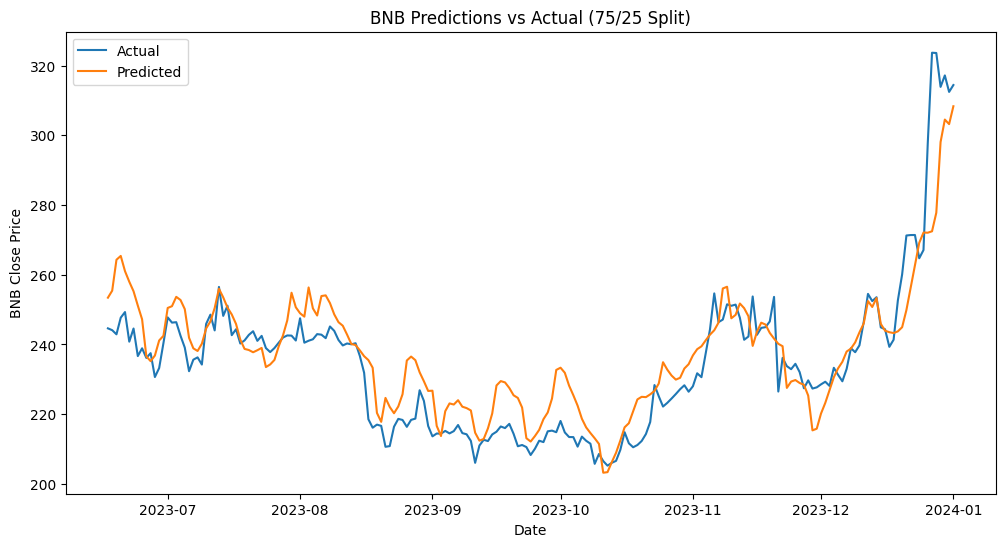

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(bnb_q3_df_plot["Actual"], label="Actual")
plt.plot(bnb_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BNB Close Price")
plt.title("BNB Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

## Saving the best model (out of accuracy) for Binance 

In [48]:
# import joblib
# joblib.dump(model_y, "Binance_base_model.pkl")

# Finetuning the models

In [49]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
grep -R "^import " .

SyntaxError: invalid syntax (3242696577.py, line 1)